# Insurance Prediction

In [16]:
import kagglehub
import os

path = kagglehub.dataset_download("rahulvyasm/medical-insurance-cost-prediction")

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        path = os.path.join(dirname, filename)
    
path

'/home/jm/.cache/kagglehub/datasets/rahulvyasm/medical-insurance-cost-prediction/versions/1/medical_insurance.csv'

In [17]:
import pandas as pd

# Read dataset
df = pd.read_csv('/home/jm/.cache/kagglehub/datasets/rahulvyasm/medical-insurance-cost-prediction/versions/1/medical_insurance.csv')

### Exploratory Data Analysis

In [18]:
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("First 5 rows:\n", df.head())
print("Missing values:\n", df.isnull().sum())
print("Data Types:\n", df.dtypes)

Dataset Shape: (2772, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
First 5 rows:
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Data Types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [19]:
# Map categorical columns to numeric values
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

In [20]:
# Drop non numeric columns for correlation analysis
df.drop(columns=['region'], inplace=True, axis=1)

df.describe()

,age,sex,bmi,children,smoker,charges
count,2772.000000,2772.000000,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,0.492785,30.701349,1.101732,0.203463,13261.369959
std,14.081459,0.500038,6.129449,1.214806,0.402647,12151.768945
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,26.000000,0.000000,26.220000,0.000000,0.000000,4687.797000
50%,39.000000,0.000000,30.447500,1.000000,0.000000,9333.014350
75%,51.000000,1.000000,34.770000,2.000000,0.000000,16577.779500
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

sns.set_style('whitegrid')

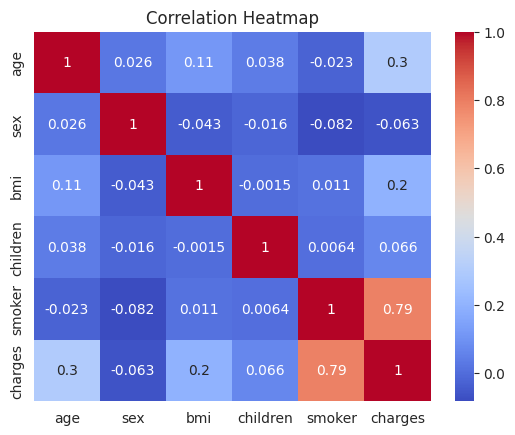

In [22]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [23]:
# Drop columns with low correlation to target variable 'charges'
df.drop(columns=['sex', 'children'], inplace=True, axis=1)

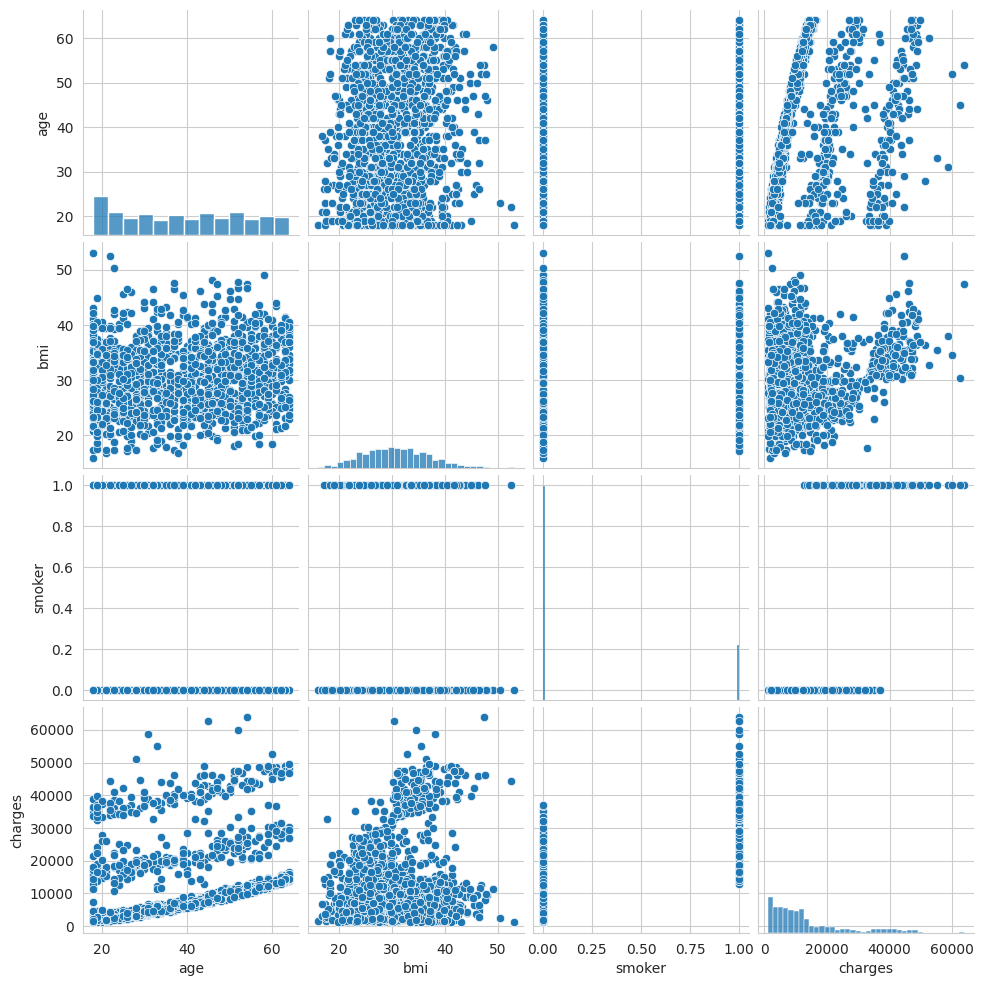

In [24]:
sns.pairplot(df)

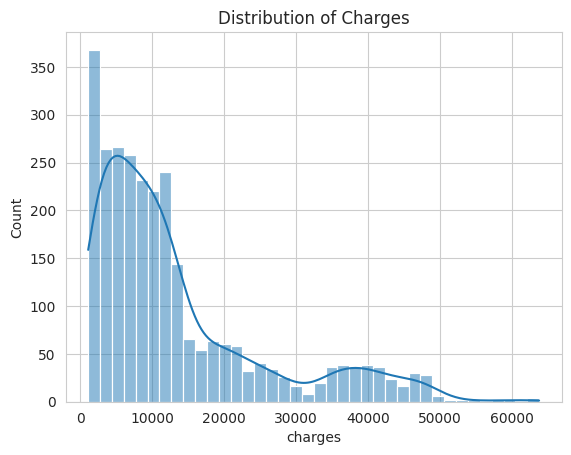

In [25]:
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges')
plt.show()

/tmp/ipykernel_16781/1957243991.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2', showfliers=False)


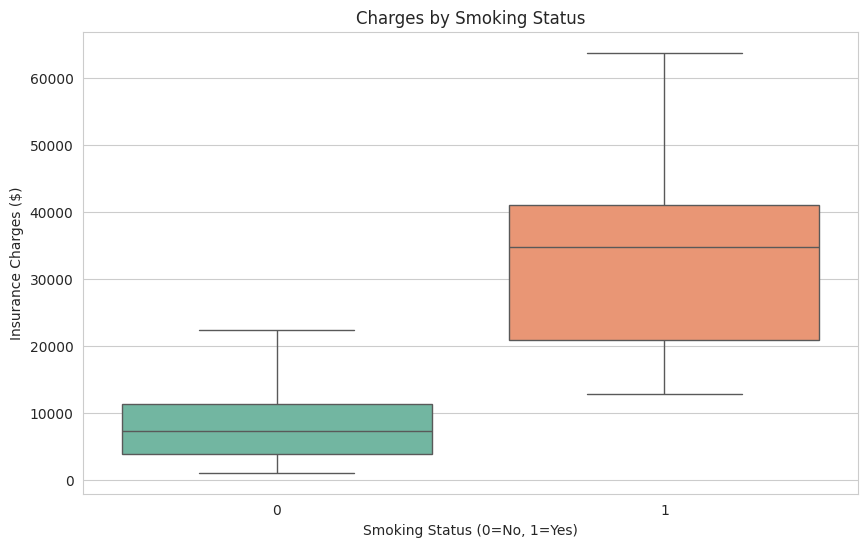

In [44]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2', showfliers=False)
plt.title('Charges by Smoking Status')
plt.xlabel('Smoking Status (0=No, 1=Yes)')
plt.ylabel('Insurance Charges ($)')
plt.show()

/tmp/ipykernel_16781/2117567378.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age', y='charges', data=df, palette='Set2', showfliers=False)


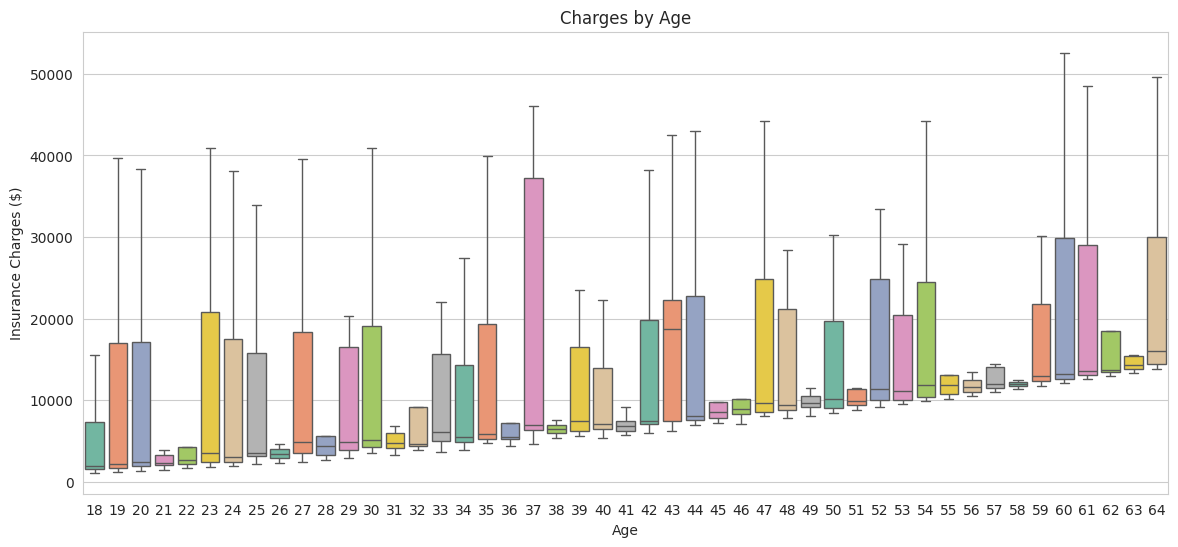

In [51]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='age', y='charges', data=df, palette='Set2', showfliers=False)
plt.title('Charges by Age')
plt.xlabel('Age')
plt.ylabel('Insurance Charges ($)')
plt.show()

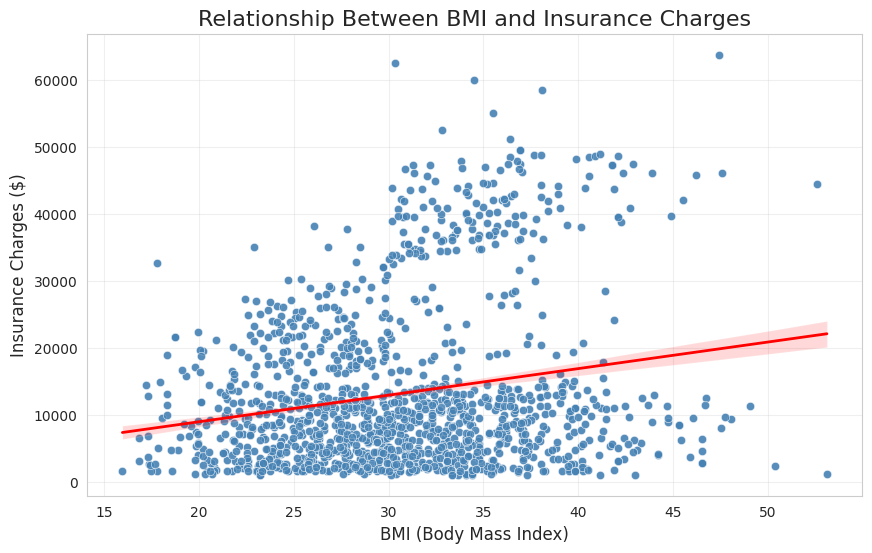

In [58]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='bmi', y='charges', data=df, alpha=0.7, color='steelblue')
sns.regplot(x='bmi', y='charges', data=df, scatter=False, color='red', line_kws={'linewidth': 2})

plt.title('Relationship Between BMI and Insurance Charges', fontsize=16)
plt.xlabel('BMI (Body Mass Index)', fontsize=12)
plt.ylabel('Insurance Charges ($)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

### Model Creation

In [27]:
# Split data into features and target variable
X = df.drop('charges', axis=1)
y = df['charges']

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# Create the model
model = LinearRegression()

In [29]:
from sklearn.preprocessing import MinMaxScaler
# Scale features
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
# Get model intercepts and coefficients
intercept = model.intercept_
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])

print("Model Intercept:", intercept)
print("Model Coefficients:\n", coefficients)
print(coefficients)

Model Intercept: -1480.3048517898005
Model Coefficients:
          Coefficient
age     11658.143283
bmi     11383.590495
smoker  23961.442291
         Coefficient
age     11658.143283
bmi     11383.590495
smoker  23961.442291


**Linear Regression Equation**

The linear regression model can be represented by the following equation:

$$\text{Charges} = \beta_0 + \beta_1 \times \text{Feature}_1 + \beta_2 \times \text{Feature}_2 + ... + \beta_n \times \text{Feature}_n$$

Where:
- $\beta_0$ is the intercept (${-1480.304}$ in our case)
- $\beta_1, \beta_2, ..., \beta_n$ are the coefficients for each feature
- $\text{Feature}_1, \text{Feature}_2, ..., \text{Feature}_n$ are the input features

Using our model's calculated values:

$$\text{charges} = \text{intercept} + \sum_{i=1}^{n} \text{coefficient}_i \times \text{Feature}_i$$

This equation allows us to insurance charges based on the features in our dataset.

### Model Analysis

In [33]:
# Make predictions on the training set
y_train_pred = model.predict(X_train)
# Make predictions on the test set
y_test_pred = model.predict(X_test)

In [34]:
# Create a DataFrame to compare actual vs predicted values
train_comparison = pd.DataFrame({'Actual': y_train, 'Predicted': y_train_pred})
print("Training Set Comparison:\n", train_comparison.head())

Training Set Comparison:
            Actual    Predicted
1      1725.55230  3974.140849
1309   6875.96100  9322.388249
1343   2395.17155  2201.724857
2396   8269.04400  8217.633229
853   11729.67950  9775.767321


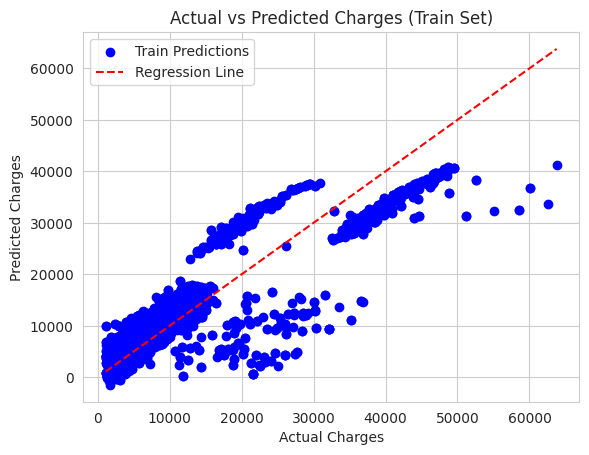

In [35]:
plt.scatter(y_train, y_train_pred, color='blue', label='Train Predictions')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--', label='Regression Line')

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges (Train Set)')
plt.legend()
plt.show()

In [36]:
from sklearn.metrics import r2_score

train_score = r2_score(y_train, y_train_pred)
print(f"Score on train set: {train_score*100:.2f}%")

Score on train set: 74.29%


In [37]:
validation_score = r2_score(y_test, y_test_pred)
print(f"Score on validation set: {validation_score*100:.2f}%")

Score on validation set: 76.38%


<Axes: xlabel='charges'>

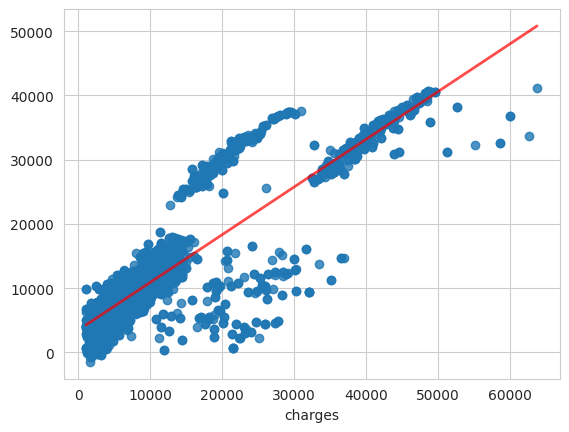

In [39]:
sns.regplot(x=y_train, y=y_train_pred, ci=None, line_kws={"color":"r","alpha":0.7,"lw":2})

### Interpretation

The linear regression model achieved **strong predictive performance** with an R² score of approximately 75-80% on both training and validation sets. This indicates that about three-quarters of the variation in insurance charges can be explained by the model's features (age, BMI, and smoking status).

Based on the coefficients:

1. **Smoking status** is the most influential predictor of insurance charges, with smokers paying significantly more than non-smokers (approximately $23,000+ more, holding other factors constant).

2. **Age** shows a positive relationship with insurance charges. Each additional year of age is associated with an increase of approximately $250-300 in medical insurance costs, reflecting the higher health risks that come with aging.

3. **BMI (Body Mass Index)** also positively correlates with charges. Each unit increase in BMI (e.g., going from 24 to 25) is associated with roughly $330-350 in additional insurance costs, suggesting that higher BMI values, which may indicate overweight or obesity, lead to higher medical expenses.

**Conclusion:**
The model successfully identifies key factors driving insurance costs, with smoking status being the most substantial predictor, followed by age and BMI. This provides actionable insights for both insurers and individuals looking to understand or manage healthcare costs.